In [59]:
# Load libraries
import pandas as pd
import geopandas as gpd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.api as sm

sns.set_style('darkgrid')
import math
from sklearn.linear_model import LogisticRegression
from scipy import stats

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

from license_model import LicenseModel

from tqdm import tqdm

In [51]:
from imblearn.over_sampling import RandomOverSampler

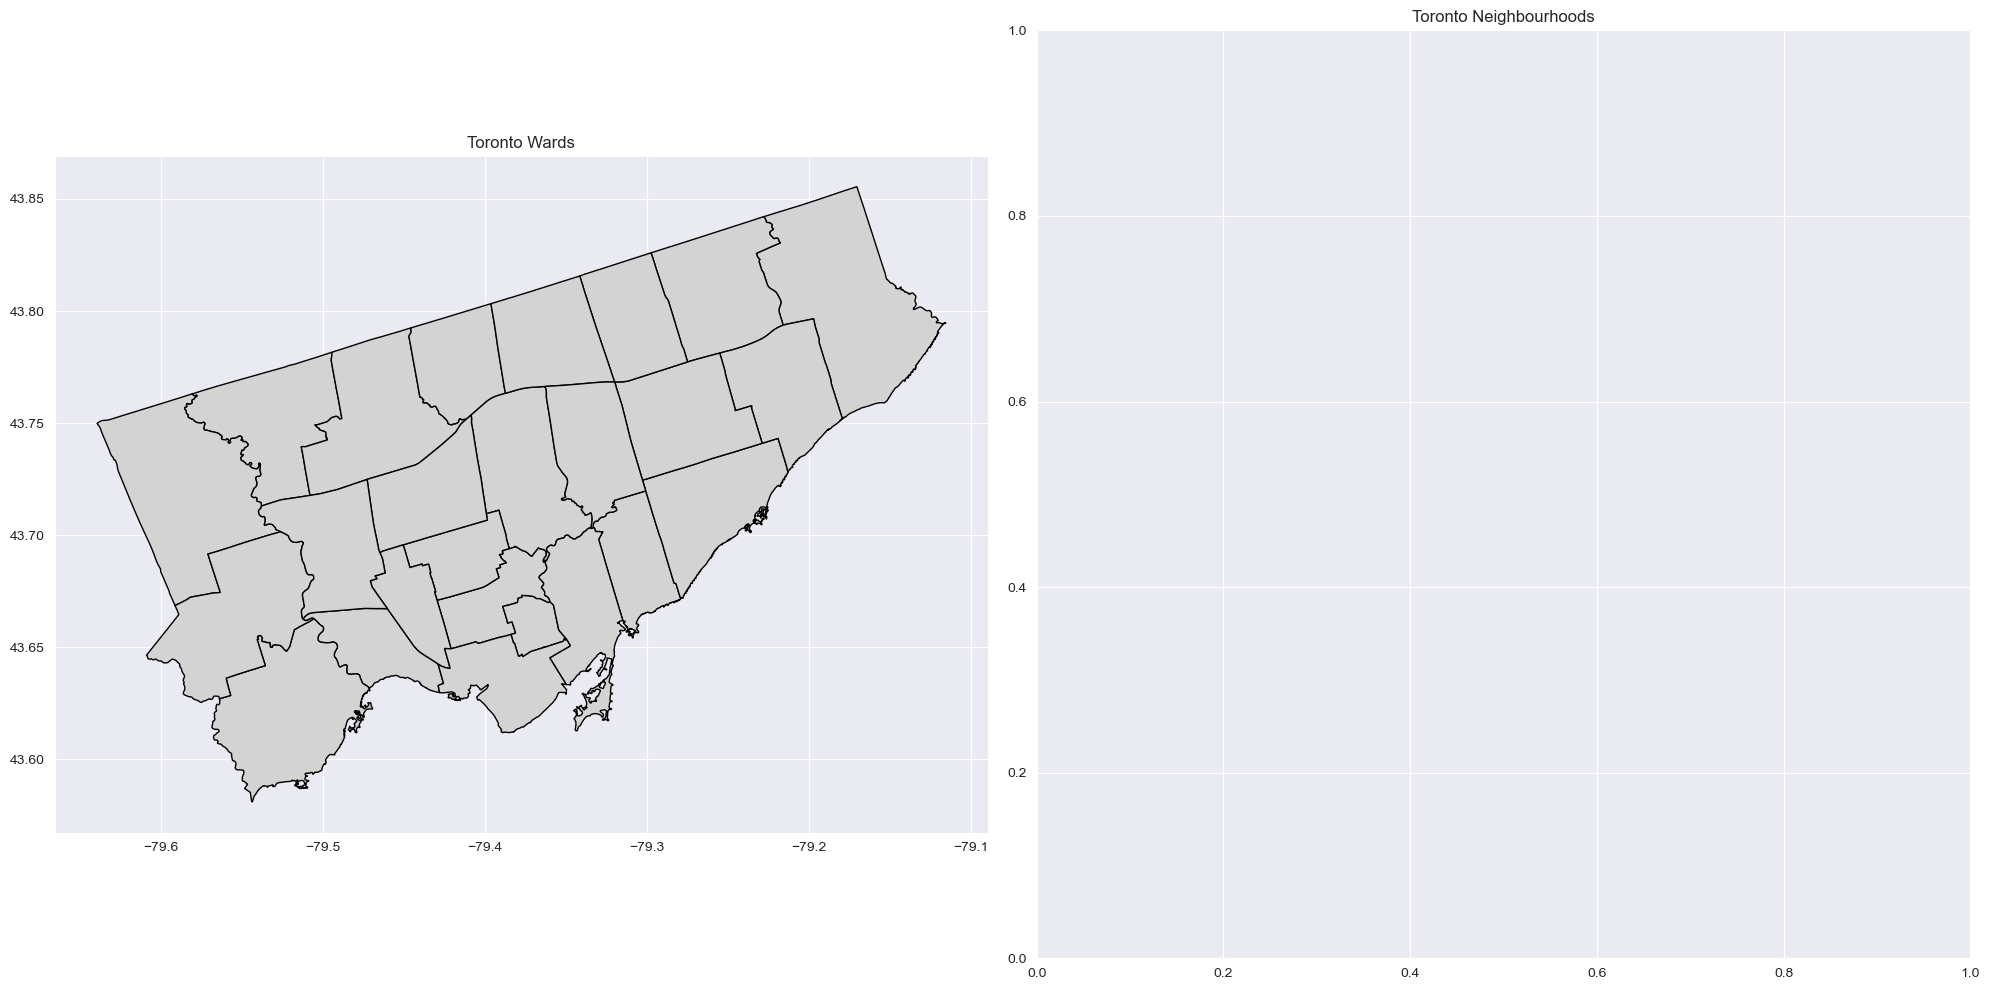

In [61]:
# Load toronto wards data
wards = gpd.read_file('data/toronto_wards_and_neighbourhoods/wards.geojson')
# neighbourhoods = gpd.read_file('data/toronto_wards_and_neighbourhoods/neighbourhoods.geojson')

# Map both plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
wards.plot(ax=ax[0], color='lightgrey', edgecolor='black')
# neighbourhoods.plot(ax=ax[1], color='lightgrey', edgecolor='black')
ax[0].set_title('Toronto Wards')
ax[1].set_title('Toronto Neighbourhoods')
plt.tight_layout()
plt.show()

# 1.0 Setup and run the model

### 1.1 Setup

In [62]:
# INPUT VARIABLES

CITY = 'Toronto'
INPUT_FILE = os.path.join('data', 'complete_city_data', 'toronto_inside_airbnb_data', 'may_3_2025.csv')
MIN_NIGHTS_FOR_LICENSE = 28
LICENSE_REGEX_PATTERN = r'^STR-\d{4}-[A-Za-z]{6}$'

In [63]:
city_model = LicenseModel(
    input_file=INPUT_FILE,
    city=CITY,
    min_nights_for_license=MIN_NIGHTS_FOR_LICENSE,
    license_regex_pattern=LICENSE_REGEX_PATTERN
)

In [64]:
city_model.load_data()
city_model.preprocess_data(print_info=True, maintain_columns=['latitude', 'longitude'])

Columns with constant values: []


In [66]:
# Convert to GeoDataFrame
city_model.listings_df = gpd.GeoDataFrame(
    city_model.listings_df,
    geometry=gpd.points_from_xy(city_model.listings_df.longitude, city_model.listings_df.latitude),
    crs='EPSG:4326'
)

# Remove latitude and longitude columns
city_model.listings_df.drop(columns=['latitude', 'longitude'], inplace=True)

In [67]:
# Open toronto_license_data_geocoded as gpd.GeoDataFrame
path = os.path.join('data', 'toronto_license_data_geocoded.csv')
toronto_license_data = gpd.read_file(path)

# Convert to GeoDataFrame based on latitude and longitude
toronto_license_data = gpd.GeoDataFrame(
    toronto_license_data,
    geometry=gpd.points_from_xy(toronto_license_data.longitude, toronto_license_data.latitude),
    crs='EPSG:4326'
)


In [8]:
# Add the wards AREA_NAME to the listings dataframe based on the geometry
city_model.listings_df = gpd.sjoin(
    city_model.listings_df,
    wards[['AREA_NAME', 'geometry']],
    how='left',
    predicate='within'
)

# Remove geometry column from the listings dataframe
city_model.listings_df.drop(columns=['index_right'], inplace=True)

city_model.listings_df.drop(columns=['geometry'], inplace=True)

In [56]:
city_model.create_legal_listing_column(print_info=False)

In [10]:
# Import scaler
from sklearn.preprocessing import MinMaxScaler

In [11]:
# # Assume 'AREA_NAME' exists in city_model.listings_df already (joined from wards)
# # df = city_model.listings_df.copy()

# # Compute % of legal listings per ward
# ward_legal_rate = city_model.listings_df.groupby("AREA_NAME")["legal_listing"].mean().rename("ward_legal_rate")

# # Merge the rate back into your main dataframe
# city_model.listings_df = city_model.listings_df.merge(ward_legal_rate, on="AREA_NAME")

# # Scale
# scaler = MinMaxScaler()
# # Scale ward_legal_rate
# city_model.listings_df['ward_legal_rate'] = scaler.fit_transform(city_model.listings_df[['ward_legal_rate']])


In [12]:
city_model.remove_columns_with_many_nan_values(maintain_columns=['price', 'bedrooms', 'bathrooms'])
city_model.transform_object_columns()
city_model.remove_low_variance_columns(print_info=True, maintain_columns=['price', 'bedrooms', 'bathrooms', 'ward_legal_rate'])
city_model.remove_missing_values(print_info=True)
city_model.listings_df.drop(columns=['neighbourhood_cleansed', 'AREA_NAME'], inplace=True)
city_model.one_hot_encode_columns(print_info=True)
city_model.remove_separation(print_info=True)
city_model.detect_and_remove_multicollinearity(print_info=False)

Removed columns with more than 5.0% missing values: ['beds', 'estimated_revenue_l365d', 'host_response_rate', 'host_response_time', 'review_scores_accuracy', 'review_scores_checkin', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_rating', 'review_scores_value', 'reviews_per_month']
Removed low variance columns: ['calculated_host_listings_count_shared_rooms', 'host_has_profile_pic', 'host_identity_verified', 'host_verifications']
Dropped categories:
room_type : Entire home/apt
Problematic columns causing separation: []


In [13]:
# Print all column names
print(city_model.listings_df.columns.tolist())

['host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'minimum_nights', 'availability_30', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'instant_bookable', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'legal_listing']


In [14]:
# # Maintain the following columns
# columns_to_maintain = ['bathrooms', 'bedrooms', 'price', 'number_of_reviews', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'legal_listing']

# # Add all columns that start with 'AREA_NAME_' to the list of columns to maintain
# columns_to_maintain += [col for col in city_model.listings_df.columns if col.startswith('AREA_NAME_')]

# # Remove all other columns
# city_model.listings_df = city_model.listings_df[columns_to_maintain]

In [15]:
city_model.listings_df 

,host_acceptance_rate,host_is_superhost,host_total_listings_count,accommodates,bathrooms,bedrooms,price,minimum_nights,availability_30,availability_90,...,number_of_reviews_l30d,number_of_reviews_ly,estimated_occupancy_l365d,instant_bookable,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,room_type_Hotel room,room_type_Private room,room_type_Shared room,legal_listing
22,90.0,0.0,2.0,4.0,2.0,2.0,269.0,2.0,23.0,71.0,...,0.0,0.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
29,100.0,1.0,1.0,2.0,1.0,1.0,92.0,18.0,29.0,61.0,...,0.0,10.0,255.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
39,52.0,1.0,1.0,6.0,1.5,2.0,240.0,4.0,24.0,46.0,...,1.0,14.0,88.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
56,100.0,0.0,3.0,2.0,1.0,1.0,254.0,14.0,23.0,68.0,...,1.0,7.0,224.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0
61,38.0,0.0,1.0,3.0,1.0,1.0,287.0,3.0,23.0,83.0,...,0.0,3.0,18.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21382,92.0,1.0,3.0,2.0,1.0,1.0,111.0,1.0,27.0,74.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,1.0
21383,75.0,0.0,14.0,2.0,1.0,1.0,91.0,1.0,29.0,89.0,...,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0
21386,94.0,0.0,24.0,2.0,1.0,1.0,61.0,1.0,30.0,90.0,...,0.0,0.0,0.0,0.0,0.0,8.0,0.0,1.0,0.0,1.0
21389,100.0,1.0,6.0,3.0,1.0,0.0,335.0,1.0,12.0,32.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0


### 1.2 Check assumptions

In [16]:
violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds()
print("Significant variables (p < 0.05) that violate linearity assumption:")
print(violating_vars)

Significant variables (p < 0.05) that violate linearity assumption:
['number_of_reviews_ly']


In [17]:
delete_instead_of_transform = True  # Set to True if you want to delete the violating variables instead of transforming them

if delete_instead_of_transform:
    # If we are deleting the violating variables, we will remove them from the DataFrame
    for var in violating_vars:
        print(f"Deleting variable: {var}")
        city_model.listings_df.drop(columns=[var], inplace=True)
else:
    print("Transforming variables to resolve linearity issues...")

    # Test multiple transformations for each violating variable
    for var in violating_vars:
        print("_" * 50)
        # Make a clean copy of the original data
        listings_data_temp = city_model.listings_df.copy()

        print(f"Testing transformations for variable: {var}")

        # Define a list of transformations to try
        transformations = {
            "log": lambda x: np.log1p(x),  # log(1 + x), handles zero values
            "sqrt": lambda x: np.sqrt(x),  # square root
            "reciprocal": lambda x: 1 / (x + 1e-6),  # reciprocal, avoids division by zero
            "square": lambda x: x**2,  # square
            "cube": lambda x: x**3,  # cube
            "exp": lambda x: np.exp(x),  # exponential
            "inverse_sqrt": lambda x: 1 / (np.sqrt(x) + 1e-6),  # inverse square root
            "log10": lambda x: np.log10(x + 1e-6),  # base-10 logarithm
            "log2": lambda x: np.log2(x + 1e-6),  # base-2 logarithm
            "zscore": lambda x: (x - np.mean(x)) / np.std(x),  # z-score normalization
            "minmax": lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)),  # min-max scaling
            "sigmoid": lambda x: 1 / (1 + np.exp(-x)),  # sigmoid transformation
            "tanh": lambda x: np.tanh(x),  # hyperbolic tangent
            "arcsinh": lambda x: np.arcsinh(x),  # inverse hyperbolic sine
            "cbrt": lambda x: np.cbrt(x),  # cube root
            "abs": lambda x: np.abs(x),  # absolute value
            "clip": lambda x: np.clip(x, 0, np.percentile(x, 95)),  # clip outliers at 95th percentile
            "rank": lambda x: x.rank(method="average"),  # rank transformation
            "binarize": lambda x: (x > np.median(x)).astype(int),  # binarize based on median
        }

        # Try each transformation
        for name, transform in transformations.items():
            try:
                # Apply the transformation
                transformed_var = transform(listings_data_temp[var])
                listings_data_temp[var] = transformed_var

                # Re-check linearity with the transformed variable
                new_violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds(
                    df_city_1=listings_data_temp
                )

                if var not in new_violating_vars:
                    print(f"Transformation '{name}' resolved linearity issue for {var}.")

                    # Update the model with the transformed variable
                    city_model.listings_df[f"{var}_{name}"] = transformed_var
                    city_model.listings_df.drop(columns=[var], inplace=True)
                    
                    break  # Stop testing further transformations for this variable
                else:
                    # print(f"Transformation '{name}' did not resolve linearity issue for {var}.")
                    pass
            except Exception as e:
                print(f"Error applying transformation '{name}' to {var}: {e}")

        else:
            # If no transformation resolved the issue
            print(f"No transformation resolved the linearity issue for {var}.")

Deleting variable: number_of_reviews_ly


Optimization terminated successfully.
         Current function value: 0.198179
         Iterations: 128
         Function evaluations: 138
         Gradient evaluations: 134
Threshold for Cook Distance = 0.0006933610677760444
Number of influential outliers: 160
Percentage of influential outliers: 2.8%


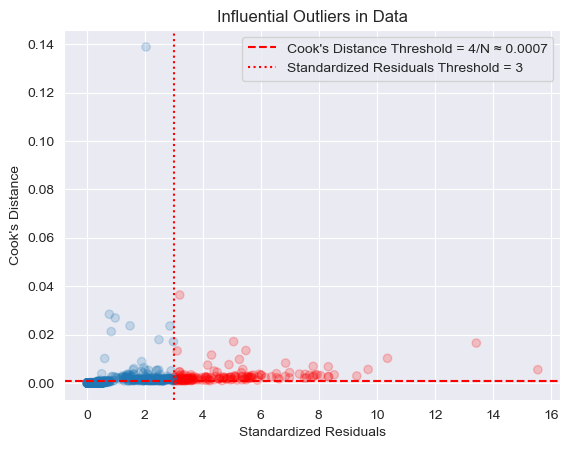

In [18]:
city_model.check_no_strongly_influential_outliers(print_info=True, show_plot=True, remove_hi_outliers=True)

## TEST OTHER MODEL TRAINING

In [19]:
from copy import deepcopy
from logit_model_class import LogitModel
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

In [20]:
from imblearn.over_sampling import SMOTE, ADASYN, SMOTENC, SMOTEN
from imblearn.combine import SMOTEENN, SMOTETomek
from itertools import combinations

In [21]:
# Make a list of all columns in the DataFrame
all_columns = city_model.listings_df.columns.tolist()

# Remove legal_listing from the list of all columns
all_columns.remove('legal_listing')

# Create all permutations of the columns
def get_column_combinations(columns, min_size=1, max_size=None):
    if max_size is None:
        max_size = len(columns)
    return [list(comb) for size in range(min_size, max_size + 1) for comb in combinations(columns, size)]
column_combinations = get_column_combinations(all_columns, min_size=2, max_size=20)

# Add legal_listing to each combination
column_combinations = [comb + ['legal_listing'] for comb in column_combinations]

# Make sure there are no duplicate combinations
column_combinations = list(set(tuple(sorted(comb)) for comb in column_combinations))

# Convert back to list of lists
column_combinations = [list(comb) for comb in column_combinations]

# Do a stratefied sample of the combinations
sample_size = 50_000  # Adjust this based on your needs
# Order the list based on size of the combinations, then do systematic sampling
column_combinations = sorted(column_combinations, key=len)
sampled_combinations = []
for i in range(0, len(column_combinations), max(1, len(column_combinations) // sample_size)):
    sampled_combinations.append(column_combinations[i])
column_combinations = sampled_combinations

In [98]:
# Loop through each combination of columns
top_scoring_f1 = 0
top_scoring_columns = None
top_scoring_threshold = 0.5
found_result = False

secondary_top_f1 = 0
secondary_top_columns = None
secondary_threshold = 0.5
secondary_result = True

third_top_f1 = 0
third_top_columns = None
third_threshold = 0.5
third_result = True

for columns in tqdm(column_combinations):
    city_model_copy = deepcopy(city_model)

    # Select only the columns in the current combination
    city_model_copy.listings_df = city_model_copy.listings_df[columns]

    city_model_copy.logit_model = LogitModel(target_column='legal_listing', test_size=0.2, random_state=42)
    city_model_copy.logit_model.prepare_data(data=city_model_copy.listings_df, use_validation=True, validation_size=0.25)

    # Determine categorical columns
    categorical_columns = ['host_is_superhost', 'instant_bookable', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
    categorical_columns += [col for col in city_model_copy.listings_df.columns if col.startswith('AREA_NAME_')]
    categorical_columns = [col for col in categorical_columns if col in city_model_copy.listings_df.columns]

    # Apply SMOTE/SMOTENC
    if categorical_columns == []:
        X_resampled, y_resampled = SMOTE().fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
    # Else if categorical_columns matches with all columns in city_model_copy (with legal_listing removed):
    elif set(categorical_columns) == set(city_model_copy.logit_model.X_train.columns):
        try:
            X_resampled, y_resampled = SMOTEN().fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
        except:
            continue
    else:
        try:
            X_resampled, y_resampled = SMOTENC(categorical_features=categorical_columns).fit_resample(
                city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train
            )
        except:
            continue

    # Fit model
    city_model_copy.logit_model.X_train = X_resampled
    city_model_copy.logit_model.y_train = y_resampled
    city_model_copy.logit_model.model = sm.Logit(y_resampled, X_resampled)
    city_model_copy.logit_model.result = city_model_copy.logit_model.model.fit(method='bfgs', maxiter=10000, disp=False)

    # Evaluate on validation set at different thresholds
    for i in range(10, 90, 10):
        threshold = i / 100.0
        scores = city_model_copy.logit_model.evaluate_model(
            selected_threshold=threshold,
            print_summary=False,
            return_types=['illegal_f1', 'illegal_precision', 'illegal_recall', 'legal_f1', 'accuracy'],
            eval_on='val'
        )

        # Save best-performing combination
        if scores['illegal_f1'] > top_scoring_f1 and scores['illegal_precision'] > 0.5 and scores['illegal_recall'] > 0.9 and scores['legal_f1'] > 0.9 and scores['accuracy'] > 0.9:
            top_scoring_f1 = scores['illegal_f1']
            top_scoring_columns = columns
            top_scoring_threshold = threshold
            found_result = True
        elif scores['illegal_f1'] > secondary_top_f1 and scores['illegal_precision'] > 0.4 and scores['illegal_recall'] > 0.9 and scores['legal_f1'] > 0.7 and scores['accuracy'] > 0.7:
            secondary_top_f1 = scores['illegal_f1']
            secondary_top_columns = columns
            secondary_threshold = threshold
            secondary_result = True
        elif scores['illegal_f1'] > third_top_f1 and scores['illegal_precision'] > 0.4 and scores['illegal_recall'] > 0.8 and scores['legal_f1'] > 0.7 and scores['accuracy'] > 0.7:
            third_top_f1 = scores['illegal_f1']
            third_top_columns = columns
            third_threshold = threshold
            third_result = True



if found_result:
    print(f"Top scoring F1: {top_scoring_f1}")
    print(f"Top scoring columns: {top_scoring_columns}")
    print(f"Top scoring threshold: {top_scoring_threshold}")
elif secondary_result:
    print(f"Secondary top scoring F1: {secondary_top_f1}")
    print(f"Secondary top scoring columns: {secondary_top_columns}")
    print(f"Secondary top scoring threshold: {secondary_threshold}")
elif third_result:
    print(f"Third top scoring F1: {third_top_f1}")
    print(f"Third top scoring columns: {third_top_columns}")
    print(f"Third top scoring threshold: {third_threshold}")
else:
    print("No suitable model found with the given criteria.")


100%|██████████| 52428/52428 [7:19:03<00:00,  1.99it/s]   

Secondary top scoring F1: 0.5714285714285714
Secondary top scoring columns: ['availability_30', 'availability_365', 'availability_90', 'bathrooms', 'calculated_host_listings_count_entire_homes', 'estimated_occupancy_l365d', 'host_acceptance_rate', 'legal_listing', 'number_of_reviews_l30d', 'room_type_Hotel room', 'room_type_Shared room']
Secondary top scoring threshold: 0.3


Secondary top scoring F1: 0.6857142857142857
Secondary top scoring columns: ['availability_30', 'availability_90', 'bedrooms', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'estimated_occupancy_l365d', 'host_acceptance_rate', 'host_is_superhost', 'legal_listing', 'number_of_reviews', 'number_of_reviews_l30d', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
Secondary top scoring threshold: 0.2

In [80]:
third_threshold

0.2

In [22]:
# Make a copy
city_model_copy = deepcopy(city_model)

In [23]:
city_model_copy.logit_model = LogitModel(target_column='legal_listing', test_size=0.2, random_state=42)
city_model_copy.logit_model.prepare_data(data=city_model_copy.listings_df, use_validation=False)

In [24]:
columns_to_keep = ['availability_30', 'availability_90', 'bedrooms', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'estimated_occupancy_l365d', 'host_acceptance_rate', 'host_is_superhost', 'legal_listing', 'number_of_reviews', 'number_of_reviews_l30d', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

city_model_copy.listings_df = city_model_copy.listings_df[columns_to_keep]

In [25]:
categorical_columns = ['host_is_superhost', 'instant_bookable', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

# Add to categorical columns all columns in city_model_copy.listings_df that begin with 'neighbourhood_cleansed_'
categorical_columns += [col for col in city_model_copy.listings_df.columns if col.startswith('AREA_NAME_')]

# Remove any columns in categorical_columns that are not in the listings_df
categorical_columns = [col for col in categorical_columns if col in city_model_copy.listings_df.columns]

In [26]:
ros = RandomOverSampler(random_state=42)
sme = SMOTEENN(random_state=42)
smt = SMOTETomek(random_state=42)

# X_resampled, y_resampled = ros.fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = SMOTE().fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = ADASYN().fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
X_resampled, y_resampled = SMOTENC(categorical_features=categorical_columns).fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = sme.fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)
# X_resampled, y_resampled = smt.fit_resample(city_model_copy.logit_model.X_train, city_model_copy.logit_model.y_train)

city_model_copy.logit_model.X_train = X_resampled
city_model_copy.logit_model.y_train = y_resampled

In [25]:
weights = city_model_copy.logit_model.y_train.map({0:10, 1:1})

In [27]:
city_model_copy.logit_model.model = sm.Logit(city_model_copy.logit_model.y_train, city_model_copy.logit_model.X_train)
# city_model_copy.logit_model.result = city_model_copy.logit_model.model.fit(weights=weights, method='bfgs', maxiter=1000)
city_model_copy.logit_model.result = city_model_copy.logit_model.model.fit(method='bfgs', maxiter=10000)

Optimization terminated successfully.
         Current function value: 0.219214
         Iterations: 119
         Function evaluations: 128
         Gradient evaluations: 124


In [28]:
# In city_model_copy.listings_df, how many listings are legal/illegal (look at unique values in legal_listing column)
print(city_model_copy.listings_df['legal_listing'].value_counts())

legal_listing
1.0    5390
0.0     219
Name: count, dtype: int64


In [49]:
city_model_copy.evaluate_model(selected_threshold=0.65, print_info=True, return_types=None)

Accuracy: 0.8681
Confusion Matrix:
[[ 43   1]
 [147 931]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.23      0.98      0.37        44
         1.0       1.00      0.86      0.93      1078

    accuracy                           0.87      1122
   macro avg       0.61      0.92      0.65      1122
weighted avg       0.97      0.87      0.90      1122



In [292]:
city_model_copy.does_data_follow_one_in_ten_rule()

Number of events (legal/illegal listings): 379
Maximum number of predictors allowed (one-in-ten rule): 37
Number of predictors in the model: 20
The model follows the one-in-ten rule.


True

### 1.3 Run Model

In [303]:
city_model.train_model(clear_existing_model=True)

Optimization terminated successfully.
         Current function value: 0.203612
         Iterations: 123
         Function evaluations: 136
         Gradient evaluations: 132
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 4615
Model:                          Logit   Df Residuals:                     4595
Method:                           MLE   Df Model:                           19
Date:                Wed, 11 Jun 2025   Pseudo R-squ.:                  0.1595
Time:                        23:09:49   Log-Likelihood:                -939.67
converged:                       True   LL-Null:                       -1118.0
Covariance Type:            nonrobust   LLR p-value:                 4.285e-64
                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [305]:
city_model.evaluate_model(selected_threshold=0.9)

Accuracy: 0.8328
Confusion Matrix:
[[ 49  27]
 [166 912]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.23      0.64      0.34        76
         1.0       0.97      0.85      0.90      1078

    accuracy                           0.83      1154
   macro avg       0.60      0.75      0.62      1154
weighted avg       0.92      0.83      0.87      1154



In [136]:
city_model.does_data_follow_one_in_ten_rule()

Number of events (legal/illegal listings): 222
Maximum number of predictors allowed (one-in-ten rule): 22
Number of predictors in the model: 43


False

In [83]:
# From city_model.logit_model.result, export the coefficients
coefficients = city_model.logit_model.result.params
coefficients

host_acceptance_rate                             0.021612
host_is_superhost                               -0.737391
host_total_listings_count                       -0.018445
accommodates                                     0.056299
bathrooms                                        0.499223
bedrooms                                        -0.509459
price                                            0.000122
minimum_nights                                   0.307121
availability_30                                 -0.028389
availability_90                                  0.014737
availability_365                                -0.000711
number_of_reviews                               -0.000593
number_of_reviews_l30d                          -0.150226
estimated_occupancy_l365d                        0.025689
instant_bookable                                -0.578319
calculated_host_listings_count_entire_homes     -0.320540
calculated_host_listings_count_private_rooms    -0.098510
room_type_Hote

# AUTOMATED CODE FOR EVERY MONTH

In [2]:
# Set up the empty DataFrame for coefficients
coefficients_df = pd.DataFrame()

In [3]:
CITY = 'Toronto'
# INPUT_FILE = os.path.join('data', 'complete_city_data', 'toronto_inside_airbnb_data', 'may_3_2025.csv')
MIN_NIGHTS_FOR_LICENSE = 28
LICENSE_REGEX_PATTERN = r'^STR-\d{4}-[A-Za-z]{6}$'

In [4]:
# Loop through every file in the data/complete_city_data/toronto_inside_airbnb_data/ directory

i = 0

for filename in os.listdir('data/complete_city_data/toronto_inside_airbnb_data/'):
    # i += 1
    # if i > 3:
    #     break

    if filename.endswith('.csv'):
        file_path = os.path.join('data', 'complete_city_data', 'toronto_inside_airbnb_data', filename)
        print(f"Processing file: {file_path}")

        city_model = LicenseModel(
            input_file=file_path,
            city=CITY,
            min_nights_for_license=MIN_NIGHTS_FOR_LICENSE,
            license_regex_pattern=LICENSE_REGEX_PATTERN
        )

        # Load the data
        city_model.load_data()
        city_model.preprocess_data(print_info=False)

        # Create legal listing column
        city_model.create_legal_listing_column(print_info=False)

        # Remove columns with many NaN values
        city_model.remove_columns_with_many_nan_values(maintain_columns=['price', 'bedrooms', 'bathrooms'], print_info=False)

        # Transform object columns
        city_model.transform_object_columns()

        # Remove low variance columns
        city_model.remove_low_variance_columns(print_info=False)

        # Remove missing values
        city_model.remove_missing_values(print_info=False)

        city_model.listings_df.drop(columns=['neighbourhood_cleansed'], inplace=True)

        # One-hot encode columns
        city_model.one_hot_encode_columns(print_info=False)

        # Remove separation
        city_model.remove_separation(print_info=False)
        
        # Detect and remove multicollinearity
        city_model.detect_and_remove_multicollinearity(print_info=False)

        # Remove violating variables
        violating_vars = city_model.check_linearity_of_independent_variables_and_log_odds()
        for var in violating_vars:
            # If price is one of the violating variables, we will not delete it
            if var == 'price':
                continue
            city_model.listings_df.drop(columns=[var], inplace=True)

        city_model.check_no_strongly_influential_outliers(print_info=False, show_plot=False, remove_hi_outliers=True)

        # Train the model
        city_model.train_model()

        # Evaluate the model
        city_model.evaluate_model(selected_threshold=0.85)

        # Get the coefficients
        coefficients = city_model.logit_model.result.params
        coefficients_df[filename] = coefficients
    
    # Delete the model to free up memory
    del city_model.logit_model
    del city_model.listings_df
    del city_model


Processing file: data\complete_city_data\toronto_inside_airbnb_data\april_7_2025.csv
Optimization terminated successfully.
         Current function value: 0.197448
         Iterations: 123
         Function evaluations: 142
         Gradient evaluations: 135
Optimization terminated successfully.
         Current function value: 0.097035
         Iterations: 131
         Function evaluations: 142
         Gradient evaluations: 139
                           Logit Regression Results                           
Dep. Variable:          legal_listing   No. Observations:                 4548
Model:                          Logit   Df Residuals:                     4530
Method:                           MLE   Df Model:                           17
Date:                Thu, 05 Jun 2025   Pseudo R-squ.:                  0.3971
Time:                        14:45:42   Log-Likelihood:                -441.31
converged:                       True   LL-Null:                       -732.00
Covariance T

In [5]:
coefficients_df

,april_7_2025.csv,august_7_2024.csv,december_8_2024.csv,february_9_2025.csv,january_9_2025.csv,july_12_2024.csv,june_10_2024.csv,march_2_2025.csv,may_3_2025.csv,november_7_2024.csv,october_5_2024.csv,september_5_2024.csv
host_acceptance_rate,0.017999,0.006620,NaN,NaN,NaN,NaN,0.016327,0.018999,0.021612,0.019522,0.017565,NaN
host_is_superhost,-0.601781,-0.419794,0.007180,-1.082734,-0.190063,0.092624,-0.330240,-1.447576,-0.737391,-0.061677,-0.173640,0.327721
bathrooms,0.804957,0.564057,0.558880,NaN,NaN,0.697715,0.613886,0.844467,0.499223,0.574433,0.512731,1.073095
bedrooms,-0.683412,-0.319080,-0.361962,0.011209,-0.017445,-0.311793,-0.279444,-0.752853,-0.509459,-0.523230,-0.245914,-0.180664
price,0.002514,0.000660,0.000156,NaN,NaN,0.000358,0.000649,0.001889,0.000122,0.000080,-0.000097,0.001980
minimum_nights,0.073978,0.043410,0.219002,0.404359,0.475344,0.237409,0.157305,0.192424,0.307121,0.186911,0.089252,0.100929
availability_30,-0.078495,-0.006243,-0.001513,-0.027160,-0.022401,0.018968,0.001867,-0.013179,-0.028389,-0.005866,-0.039093,-0.050875
availability_90,0.026422,-0.008769,0.013023,0.018162,0.019322,-0.000332,0.000768,0.007914,0.014737,0.004783,0.011543,0.023099
availability_365,0.000299,0.003496,0.000141,0.001038,0.001673,0.002938,0.001333,-0.000297,-0.000711,-0.000212,0.001538,0.001118
number_of_reviews,-0.001541,0.014153,0.016809,0.001243,0.040600,0.005404,0.014784,-0.000582,-0.000593,0.014619,0.016988,0.011869


In [109]:
# For each column, rename to remove the .csv extension
coefficients_df.columns = [re.sub(r'\.csv$', '', col) for col in coefficients_df.columns]

In [124]:
# Make a copy 
coefficients_df_copy = coefficients_df.copy()

In [131]:
# Each column name is in the format "month_day_year". The month is by full name, the day is a number, and the year is a four-digit number. Reorder the columns to be in chronological order
coefficients_df_copy = coefficients_df.copy()
# Start by removing underscores
coefficients_df_copy.columns = [re.sub(r'_', ' ', col) for col in coefficients_df_copy.columns]

# Now convert the month names to numbers
month_mapping = {
    'january': '01',
    'february': '02',
    'march': '03',
    'april': '04',
    'may': '05',
    'june': '06',
    'july': '07',
    'august': '08',
    'september': '09',
    'october': '10',
    'november': '11',
    'december': '12'
}
def convert_month_name_to_number(month_name):
    month_name = month_name.lower()
    return month_mapping.get(month_name, month_name)
coefficients_df_copy.columns = [
    re.sub(r'(\w+)\s(\d{1,2})\s(\d{4})', lambda m: f"{convert_month_name_to_number(m.group(1))} {m.group(2)} {m.group(3)}", col)
    for col in coefficients_df_copy.columns
]

# Now convert to year-month-day format
coefficients_df_copy.columns = [
    re.sub(r'(\d{2})\s(\d{1,2})\s(\d{4})', lambda m: f"{m.group(3)}-{int(m.group(1)):02d}-{int(m.group(2)):02d}", col)
    for col in coefficients_df_copy.columns
]

# Change day to two digits
coefficients_df_copy.columns = [
    re.sub(r'(\d{1,2})-(\d{1,2})-(\d{4})', lambda m: f"{int(m.group(1)):02d}-{int(m.group(2)):02d}-{m.group(3)}", col)
    for col in coefficients_df_copy.columns
]

# Now sort the columns
coefficients_df_copy = coefficients_df_copy.reindex(sorted(coefficients_df_copy.columns), axis=1)

In [137]:
coefficients_df_copy

,2024-06-10,2024-07-12,2024-08-07,2024-09-05,2024-10-05,2024-11-07,2024-12-08,2025-01-09,2025-02-09,2025-03-02,2025-04-07,2025-05-03
host_acceptance_rate,0.018018,0.015951,0.003308,0.017905,0.019478,0.015547,0.016167,0.020959,0.018901,0.019762,0.020292,0.019881
host_is_superhost,-0.048834,-0.205287,-0.186373,0.022533,-0.288232,-0.248164,-0.190506,-0.477881,-0.582392,-0.715130,-0.280938,-0.224472
host_listings_count,NaN,NaN,NaN,NaN,-0.017207,NaN,NaN,NaN,NaN,NaN,0.012792,NaN
accommodates,-0.053863,-0.102712,-0.115961,-0.083733,-0.072391,-0.010680,-0.037348,0.004369,-0.009017,-0.036202,-0.073207,0.020577
bathrooms,0.403579,0.491721,0.356036,0.327144,0.405497,0.433669,0.405916,NaN,NaN,0.338255,0.436665,0.235484
bedrooms,-0.262920,-0.276421,-0.196249,-0.230845,-0.161400,-0.288219,-0.340529,-0.177752,-0.092684,-0.350495,-0.335644,-0.274344
price,0.000526,0.001310,0.000688,0.001385,0.000406,0.000104,0.000136,NaN,NaN,0.001437,0.001950,0.000352
minimum_nights,0.088138,0.127827,0.032934,0.056342,0.084148,0.153117,0.159644,0.167556,0.133555,0.118459,0.059766,0.128158
availability_30,0.001044,0.010532,-0.008273,-0.033884,-0.015787,-0.000968,-0.008834,-0.009254,-0.010405,-0.004475,-0.028507,-0.013049
availability_90,0.000234,-0.002674,-0.003244,0.010455,0.005113,0.004888,0.007178,0.007277,0.008018,0.004943,0.010044,0.005517


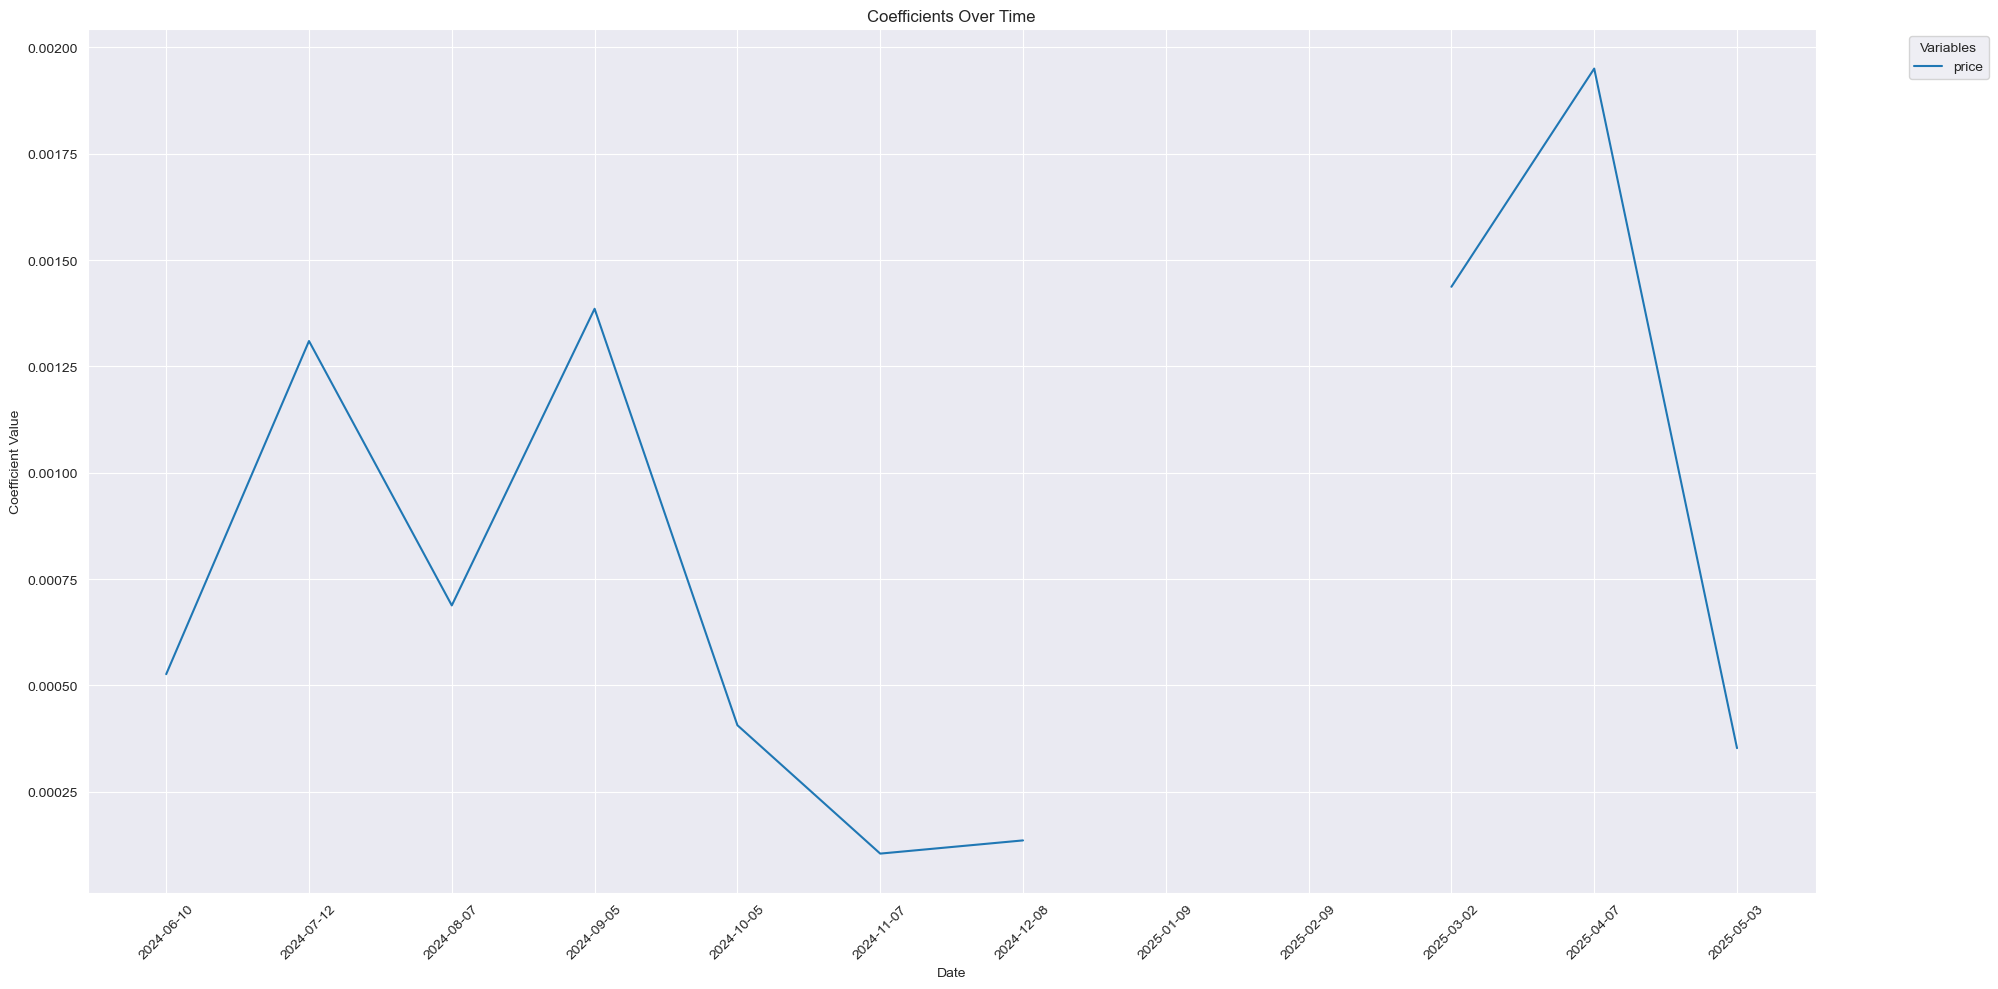

In [140]:
# Plot the coefficients in a line plot (columns are dates, so the x-axis is the columns, and the y-axis is the coefficients) Colour each line by the row
# Plot only the coefficients for "price", "bedrooms", and "bathrooms"
plt.figure(figsize=(20, 10))
for index, row in coefficients_df_copy.iterrows():
    if index in ["price"]:
        plt.plot(coefficients_df_copy.columns, row, label=index)
plt.title('Coefficients Over Time')
plt.xlabel('Date')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.legend(title='Variables', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [138]:
# Save the coefficients DataFrame to a CSV file
coefficients_df_copy.to_csv('data/toronto_airbnb_coefficients.csv', index=True)